# Focused Comparison: Five Selected Models

This notebook compares exactly these five trained runs:

- `unprocessed/default_balanced/sota_best`
- `processed/default_balanced/unet_mlp_late_fusion` from the top-04 summary slot
- `processed/default_balanced/cnn_mlp_intermediate_fusion`
- `processed/default_balanced/cvt_mlp_early_fusion`
- `processed/default_balanced/cnn_tabtransformer_intermediate_fusion`

It reads the saved CSV artifacts from `Results_Logs`, recomputes comparison visuals, and saves the generated figures under `Results_Figures/selected_5_model_comparison`.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "ggplot")

ROOT = Path("/home/zeus/content/IOT_fusion")
LOG_ROOT = ROOT / "Results_Logs"
FIG_OUT = ROOT / "Results_Figures" / "selected_5_model_comparison"
FIG_OUT.mkdir(parents=True, exist_ok=True)

MODELS = [
    {
        "short": "SOTA unprocessed",
        "label": "unprocessed/default_balanced/sota_best",
        "dataset": "unprocessed",
        "variant": "default_balanced",
        "experiment": "sota_best",
    },
    {
        "short": "Top-04 U-Net late",
        "label": "top_04 processed/default_balanced/unet_mlp_late_fusion",
        "dataset": "processed",
        "variant": "default_balanced",
        "experiment": "unet_mlp_late_fusion",
    },
    {
        "short": "CNN+MLP inter",
        "label": "processed/default_balanced/cnn_mlp_intermediate_fusion",
        "dataset": "processed",
        "variant": "default_balanced",
        "experiment": "cnn_mlp_intermediate_fusion",
    },
    {
        "short": "CvT+MLP early",
        "label": "processed/default_balanced/cvt_mlp_early_fusion",
        "dataset": "processed",
        "variant": "default_balanced",
        "experiment": "cvt_mlp_early_fusion",
    },
    {
        "short": "CNN+TabTransformer inter",
        "label": "processed/default_balanced/cnn_tabtransformer_intermediate_fusion",
        "dataset": "processed",
        "variant": "default_balanced",
        "experiment": "cnn_tabtransformer_intermediate_fusion",
    },
]

def run_dir(model):
    return LOG_ROOT / model["dataset"] / model["variant"] / model["experiment"]

missing = []
for model in MODELS:
    base = run_dir(model)
    for fname in [
        "result_summary.csv",
        "epoch_metrics.csv",
        "classification_report.csv",
        "confusion_matrix.csv",
        "test_predictions.csv",
    ]:
        if not (base / fname).exists():
            missing.append(str(base / fname))
if missing:
    raise FileNotFoundError("Missing expected artifacts:\n" + "\n".join(missing))

display(Markdown(f"Output figures will be written to `{FIG_OUT}`."))

Output figures will be written to `/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison`.

In [2]:
summaries = []
epochs = {}
reports = {}
confusions = {}
preds = {}

for model in MODELS:
    base = run_dir(model)
    summary = pd.read_csv(base / "result_summary.csv").iloc[0].to_dict()
    summary["display_name"] = model["short"]
    summary["requested_label"] = model["label"]
    summary["artifact_dir"] = str(base)
    summaries.append(summary)

    epochs[model["short"]] = pd.read_csv(base / "epoch_metrics.csv")

    report = pd.read_csv(base / "classification_report.csv")
    if "Unnamed: 0" in report.columns:
        report = report.rename(columns={"Unnamed: 0": "class"})
    reports[model["short"]] = report

    cm = pd.read_csv(base / "confusion_matrix.csv")
    if "Unnamed: 0" in cm.columns:
        cm = cm.rename(columns={"Unnamed: 0": "class"}).set_index("class")
    confusions[model["short"]] = cm

    preds[model["short"]] = pd.read_csv(base / "test_predictions.csv")

summary_df = pd.DataFrame(summaries)

# Loss-aware combined score used in the final summary.
for col in ["test_f1_macro", "test_bacc", "test_auc", "test_acc", "final_val_loss", "final_train_loss"]:
    summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")
summary_df["loss_score"] = 1.0 / (
    1.0
    + summary_df["final_val_loss"]
    + (summary_df["final_val_loss"] - summary_df["final_train_loss"]).abs()
)
summary_df["combined_score"] = (
    0.35 * summary_df["test_f1_macro"]
    + 0.25 * (summary_df["test_bacc"] / 100.0)
    + 0.25 * summary_df["test_auc"]
    + 0.10 * (summary_df["test_acc"] / 100.0)
    + 0.05 * summary_df["loss_score"]
)

show_cols = [
    "display_name",
    "dataset_source",
    "variant",
    "experiment_name",
    "test_acc",
    "test_bacc",
    "test_auc",
    "test_f1_macro",
    "test_loss",
    "final_train_loss",
    "final_val_loss",
    "combined_score",
]
table = summary_df[show_cols].copy()
display(table.sort_values("combined_score", ascending=False).style.format({
    "test_acc": "{:.2f}",
    "test_bacc": "{:.2f}",
    "test_auc": "{:.4f}",
    "test_f1_macro": "{:.4f}",
    "test_loss": "{:.4f}",
    "final_train_loss": "{:.4f}",
    "final_val_loss": "{:.4f}",
    "combined_score": "{:.4f}",
}))
table.to_csv(FIG_OUT / "selected_5_summary_table.csv", index=False)

,display_name,dataset_source,variant,experiment_name,test_acc,test_bacc,test_auc,test_f1_macro,test_loss,final_train_loss,final_val_loss,combined_score
0,SOTA unprocessed,unprocessed,default_balanced,sota_best,78.26,73.75,0.9596,0.7284,0.4640,0.3891,0.4469,0.7907
1,Top-04 U-Net late,processed,default_balanced,unet_mlp_late_fusion,76.09,71.59,0.9377,0.6918,0.9452,0.8063,0.9006,0.7567
2,CNN+MLP inter,processed,default_balanced,cnn_mlp_intermediate_fusion,76.09,67.38,0.9098,0.6847,0.9961,0.7630,0.8582,0.7372
4,CNN+TabTransformer inter,processed,default_balanced,cnn_tabtransformer_intermediate_fusion,71.30,60.86,0.8787,0.5831,1.0689,1.0006,1.1691,0.6686
3,CvT+MLP early,processed,default_balanced,cvt_mlp_early_fusion,64.35,50.22,0.8595,0.4981,1.2955,0.7785,1.3597,0.5961


## Overall Test Metrics

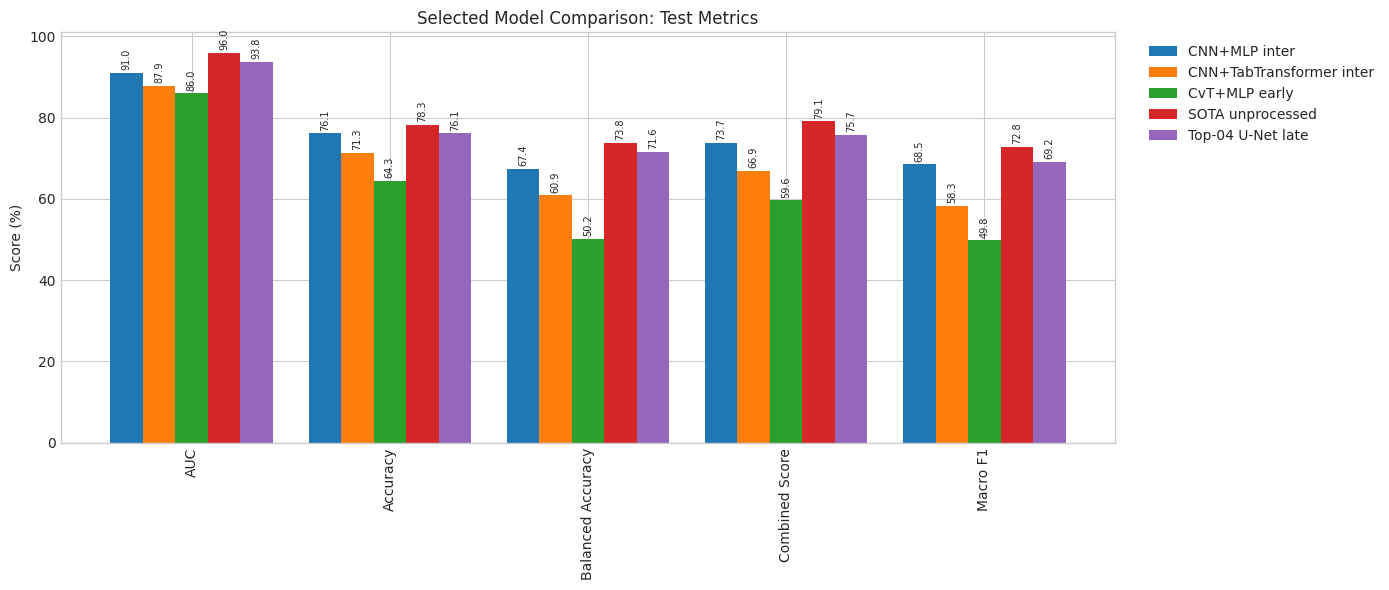

In [3]:
metric_long = summary_df[["display_name", "test_acc", "test_bacc", "test_auc", "test_f1_macro", "combined_score"]].copy()
metric_long["test_auc"] *= 100
metric_long["test_f1_macro"] *= 100
metric_long["combined_score"] *= 100
metric_long = metric_long.rename(columns={
    "test_acc": "Accuracy",
    "test_bacc": "Balanced Accuracy",
    "test_auc": "AUC",
    "test_f1_macro": "Macro F1",
    "combined_score": "Combined Score",
}).melt(id_vars="display_name", var_name="Metric", value_name="Value")

pivot = metric_long.pivot(index="Metric", columns="display_name", values="Value")
ax = pivot.plot(kind="bar", figsize=(14, 6), width=0.82)
ax.set_title("Selected Model Comparison: Test Metrics")
ax.set_ylabel("Score (%)")
ax.set_xlabel("")
ax.set_ylim(0, max(100, metric_long["Value"].max() + 5))
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=7, rotation=90, padding=2)
plt.tight_layout()
plt.savefig(FIG_OUT / "selected_5_metric_bars.png", dpi=180, bbox_inches="tight")
plt.show()

## Accuracy, Balanced Accuracy, AUC, Macro F1 Radar Chart

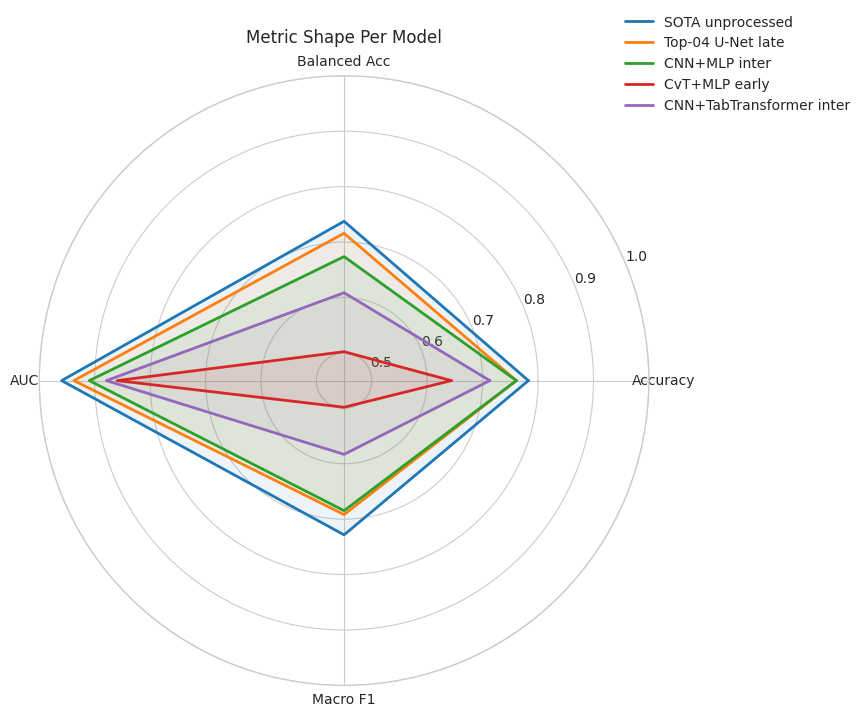

In [4]:
radar_metrics = ["test_acc", "test_bacc", "test_auc", "test_f1_macro"]
radar_labels = ["Accuracy", "Balanced Acc", "AUC", "Macro F1"]
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)
for _, row in summary_df.iterrows():
    values = [
        row["test_acc"] / 100.0,
        row["test_bacc"] / 100.0,
        row["test_auc"],
        row["test_f1_macro"],
    ]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["display_name"])
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_ylim(0.45, 1.0)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_title("Metric Shape Per Model", pad=24)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12))
plt.tight_layout()
plt.savefig(FIG_OUT / "selected_5_radar_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

## Loss and Generalization Gap

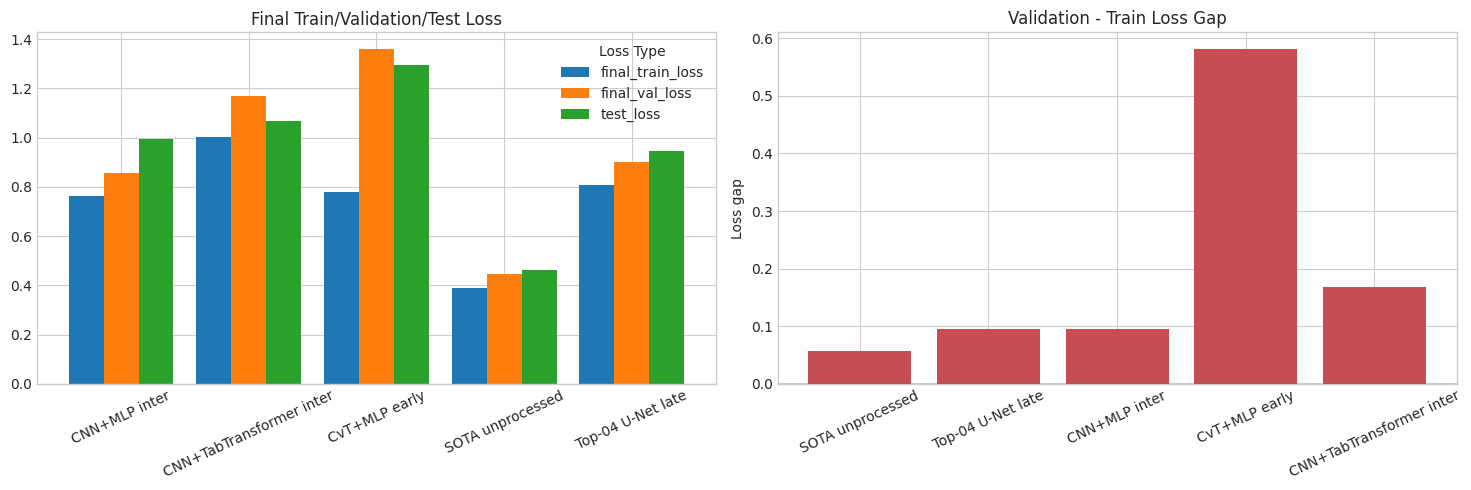

In [5]:
loss_df = summary_df[["display_name", "final_train_loss", "final_val_loss", "test_loss"]].copy()
loss_df["val_train_gap"] = loss_df["final_val_loss"] - loss_df["final_train_loss"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
loss_long = loss_df.melt(
    id_vars="display_name",
    value_vars=["final_train_loss", "final_val_loss", "test_loss"],
    var_name="Loss Type",
    value_name="Loss",
)
loss_pivot = loss_long.pivot(index="display_name", columns="Loss Type", values="Loss")
loss_pivot.plot(kind="bar", ax=axes[0], width=0.82)
axes[0].set_title("Final Train/Validation/Test Loss")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(loss_df["display_name"], loss_df["val_train_gap"], color="#c44e52")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Validation - Train Loss Gap")
axes[1].set_xlabel("")
axes[1].set_ylabel("Loss gap")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(FIG_OUT / "selected_5_loss_gap.png", dpi=180, bbox_inches="tight")
plt.show()

## Epoch Curves

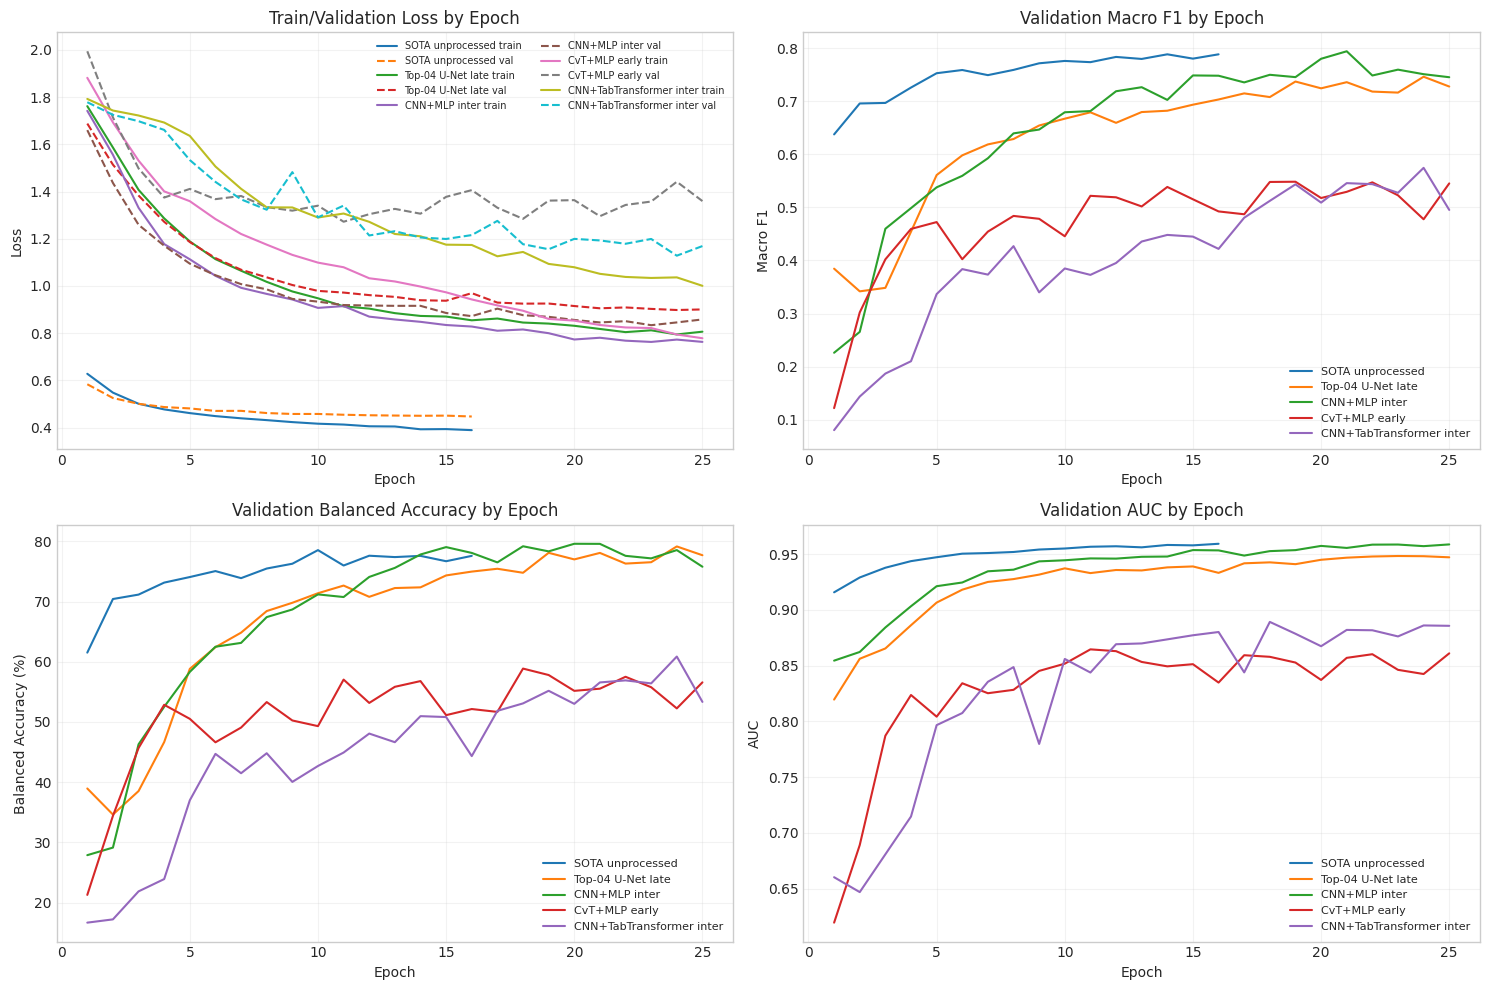

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()

for name, hist in epochs.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], label=f"{name} train")
    axes[0].plot(hist["epoch"], hist["val_loss"], linestyle="--", label=f"{name} val")
    axes[1].plot(hist["epoch"], hist["val_f1_macro"], label=name)
    axes[2].plot(hist["epoch"], hist["val_bacc"], label=name)
    axes[3].plot(hist["epoch"], hist["val_auc"], label=name)

axes[0].set_title("Train/Validation Loss by Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_title("Validation Macro F1 by Epoch")
axes[1].set_ylabel("Macro F1")
axes[2].set_title("Validation Balanced Accuracy by Epoch")
axes[2].set_ylabel("Balanced Accuracy (%)")
axes[3].set_title("Validation AUC by Epoch")
axes[3].set_ylabel("AUC")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.25)
axes[0].legend(fontsize=7, ncol=2)
for ax in axes[1:]:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_OUT / "selected_5_epoch_curves.png", dpi=180, bbox_inches="tight")
plt.show()

## Micro-Average ROC Curves

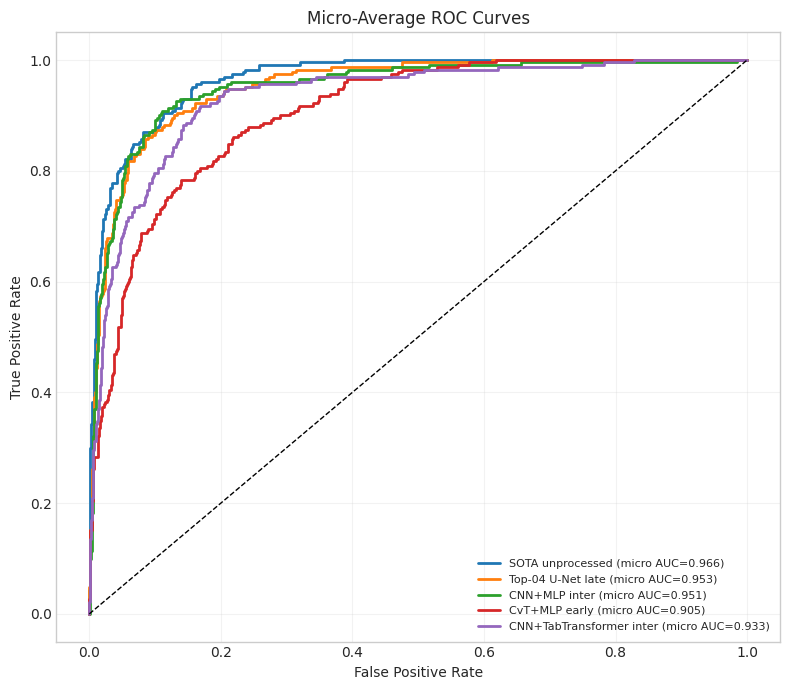

,display_name,micro_auc
0,SOTA unprocessed,0.9660
1,Top-04 U-Net late,0.9532
2,CNN+MLP inter,0.9510
4,CNN+TabTransformer inter,0.9330
3,CvT+MLP early,0.9053


In [7]:
plt.figure(figsize=(8, 7))
roc_rows = []

for name, df in preds.items():
    prob_cols = [c for c in df.columns if c.startswith("prob_")]
    class_names = [c.replace("prob_", "") for c in prob_cols]
    y_true = df["y_true"].to_numpy()
    y_score = df[prob_cols].to_numpy()
    labels = np.arange(len(class_names))
    y_bin = label_binarize(y_true, classes=labels)
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    roc_rows.append({"display_name": name, "micro_auc": roc_auc})
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (micro AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
plt.title("Micro-Average ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8, loc="lower right")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_OUT / "selected_5_micro_roc.png", dpi=180, bbox_inches="tight")
plt.show()

display(pd.DataFrame(roc_rows).sort_values("micro_auc", ascending=False).style.format({"micro_auc": "{:.4f}"}))

## Per-Class F1 Heatmap

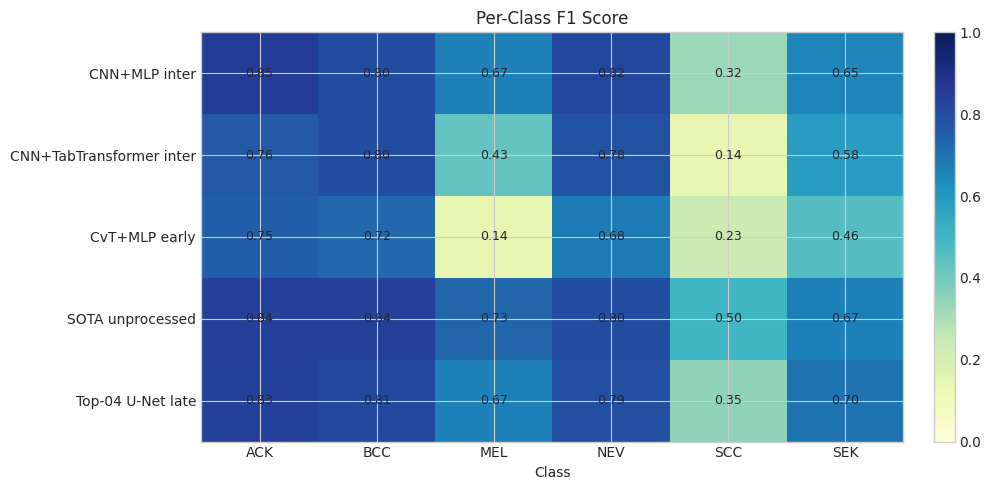

In [8]:
class_rows = []
for name, report in reports.items():
    report = report.copy()
    report = report[report["class"].isin(["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"])]
    for _, row in report.iterrows():
        class_rows.append({
            "display_name": name,
            "class": row["class"],
            "f1_score": row["f1-score"],
            "recall": row["recall"],
            "precision": row["precision"],
            "support": row["support"],
        })
class_df = pd.DataFrame(class_rows)
f1_pivot = class_df.pivot(index="display_name", columns="class", values="f1_score")

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(f1_pivot.to_numpy(dtype=float), cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(f1_pivot.columns)))
ax.set_xticklabels(f1_pivot.columns)
ax.set_yticks(np.arange(len(f1_pivot.index)))
ax.set_yticklabels(f1_pivot.index)
for i in range(f1_pivot.shape[0]):
    for j in range(f1_pivot.shape[1]):
        val = f1_pivot.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.title("Per-Class F1 Score")
plt.xlabel("Class")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_OUT / "selected_5_per_class_f1_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

class_df.to_csv(FIG_OUT / "selected_5_per_class_metrics.csv", index=False)

## Normalized Confusion Matrices

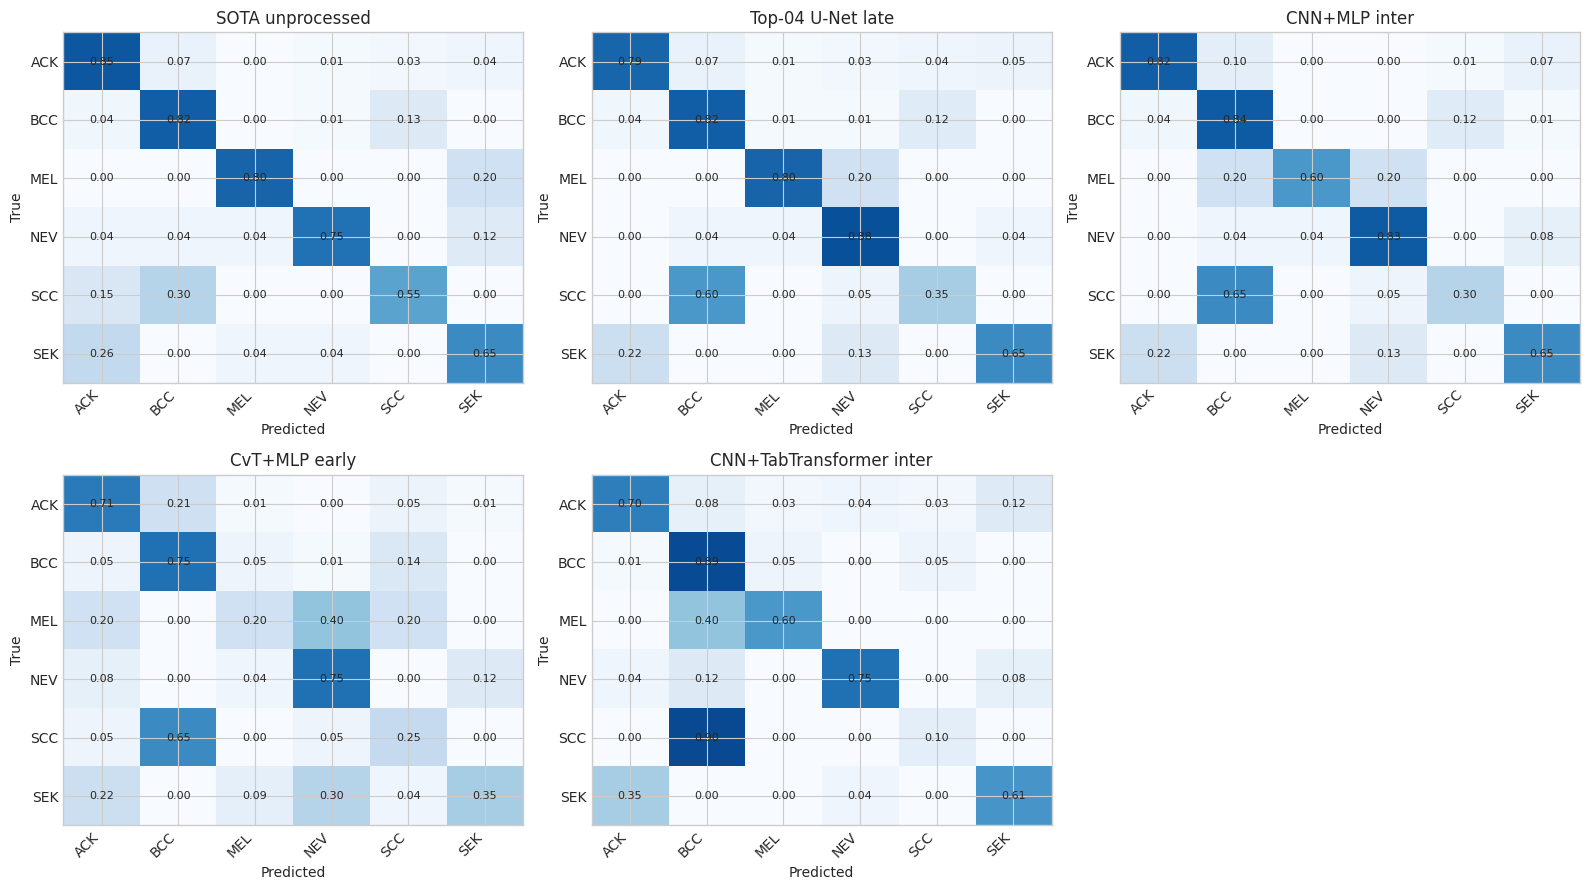

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
classes = ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]

for ax, (name, cm) in zip(axes, confusions.items()):
    cm = cm.loc[classes, classes].astype(float)
    cm_norm = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    im = ax.imshow(cm_norm.to_numpy(dtype=float), cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(classes)))
    ax.set_yticklabels(classes)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f"{cm_norm.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_OUT / "selected_5_normalized_confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

## Where The Figures Were Saved

In [10]:
saved = sorted(FIG_OUT.glob("selected_5_*"))
for path in saved:
    print(path)

/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_epoch_curves.png
/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_loss_gap.png
/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_metric_bars.png
/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_micro_roc.png
/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_normalized_confusion_matrices.png
/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_per_class_f1_heatmap.png
/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_per_class_metrics.csv
/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_radar_metrics.png
/home/zeus/content/IOT_fusion/Results_Figures/selected_5_model_comparison/selected_5_summary_table.csv
